# AI-Based Recommendation System

## Netflix Movies and TV Shows Recommendation System

### Business Problem

Streaming platforms contain thousands of movies and TV shows, making it difficult for users to discover content that matches their interests.

The objective of this project is to build an AI-based recommendation system that analyzes the characteristics of Netflix titles and recommends similar content based on patterns learned from the available data.

This notebook demonstrates the complete recommendation workflow, including data understanding, exploratory analysis, feature engineering, recommendation logic, evaluation strategy, ethical considerations, and deployment planning.

In [1]:
import pandas as pd

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 8807
Columns : 12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe(include="object").T

,count,unique,top,freq
show_id,8807,8807,s1,1
type,8807,2,Movie,6131
title,8807,8807,Dick Johnson Is Dead,1
director,6173,4528,Rajiv Chilaka,19
cast,7982,7692,David Attenborough,19
country,7976,748,United States,2818
date_added,8797,1767,"January 1, 2020",109
rating,8803,17,TV-MA,3207
duration,8804,220,1 Season,1793
listed_in,8807,514,"Dramas, International Movies",362


# Data Cleaning

Before developing the recommendation system, the dataset is examined for missing values, duplicate records, and inconsistent data.

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

print("Duplicate records removed.")

Duplicate records removed.


In [11]:
columns = [
    "director",
    "cast",
    "country",
    "rating",
    "duration",
    "listed_in",
    "description"
]

for column in columns:
    df[column] = df[column].fillna("Unknown")

In [12]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [13]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Observation

The dataset contains information about Netflix movies and TV shows, including titles, genres, directors, cast members, release years, and descriptions. Missing values have been handled without removing valuable records.

# Exploratory Data Analysis

The purpose of exploratory data analysis is to understand the distribution of Netflix content and identify useful patterns before building the recommendation engine.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

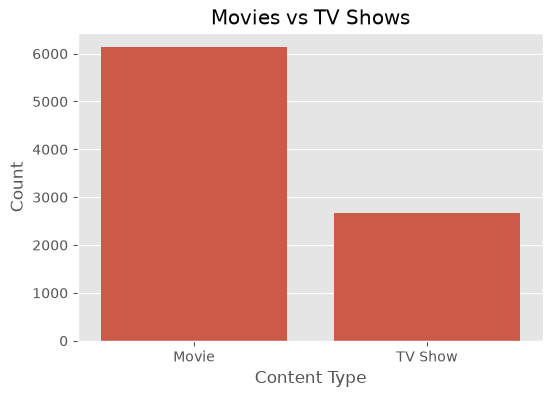

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

### Insight

Movies make up the majority of Netflix content, while TV Shows represent a smaller portion of the catalog.

In [16]:
top_countries = (
    df["country"]
    .value_counts()
    .head(10)
)

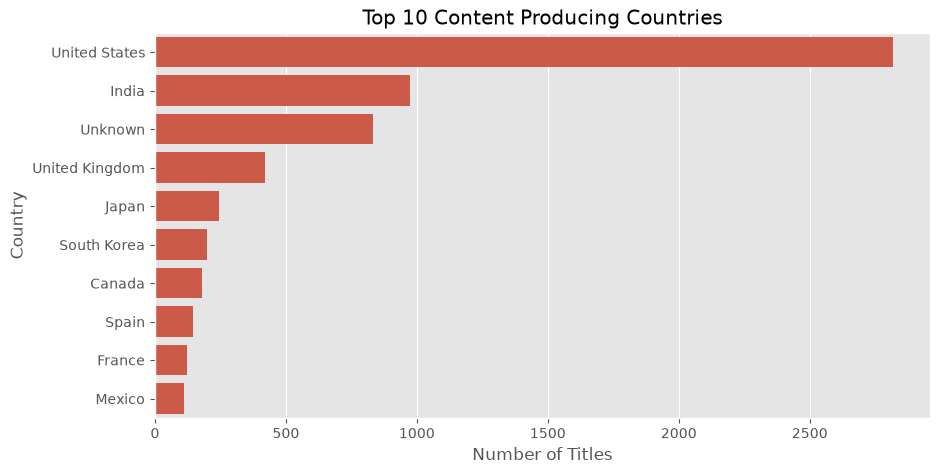

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### Insight

A few countries contribute a significant portion of Netflix's catalog, indicating regional concentration in content production.

In [18]:
top_genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

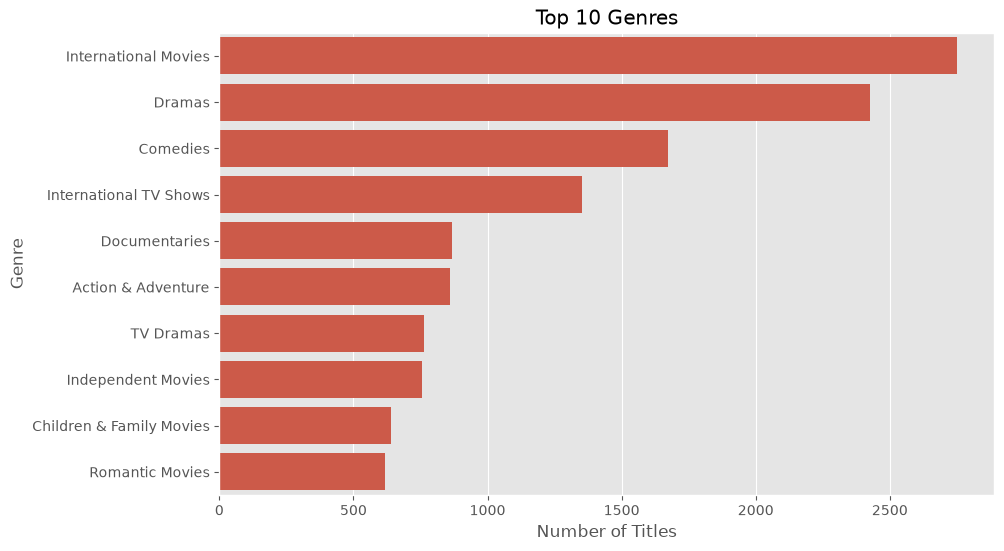

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

### Insight

Drama, International Movies, and Comedy are among the most represented genres in the dataset. Understanding genre popularity helps explain recommendation patterns.

# Pattern Learning

To identify similarities between Netflix titles, important textual information such as genres, directors, cast members, and descriptions is combined into a single feature.

This combined information is transformed into numerical vectors using TF-IDF (Term Frequency-Inverse Document Frequency), enabling the recommendation engine to measure similarity between titles.

In [20]:
df["combined_features"] = (
    df["listed_in"] + " " +
    df["director"] + " " +
    df["cast"] + " " +
    df["description"]
)

df[["title", "combined_features"]].head()

,title,combined_features
0,Dick Johnson Is Dead,Documentaries Kirsten Johnson Unknown As her f...
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysterie..."
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,"Docuseries, Reality TV Unknown Unknown Feuds, ..."
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ..."


### Observation

Each Netflix title is now represented by a single text feature containing important information that describes the content. This combined feature will be used for learning similarities between titles.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(df["combined_features"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (8807, 49941)


### Pattern Learning

The TF-IDF algorithm converts textual information into numerical vectors while assigning greater importance to distinctive words and reducing the influence of frequently occurring words.

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

In [24]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity matrix created successfully.")

Similarity matrix created successfully.


In [25]:
similarity_matrix.shape

(8807, 8807)

# Recommendation Logic

The recommendation engine compares every Netflix title with all other titles using cosine similarity. Titles with the highest similarity scores are recommended to the user.

In [26]:
title_index = pd.Series(
    df.index,
    index=df["title"]
).drop_duplicates()

title_index.head()

title
Dick Johnson Is Dead     0
Blood & Water            1
Ganglands                2
Jailbirds New Orleans    3
Kota Factory             4
dtype: int64

In [27]:
title_index = pd.Series(
    df.index,
    index=df["title"]
).drop_duplicates()

title_index.head()

title
Dick Johnson Is Dead     0
Blood & Water            1
Ganglands                2
Jailbirds New Orleans    3
Kota Factory             4
dtype: int64

In [28]:
def recommend_titles(title, number_of_recommendations=10):

    if title not in title_index:
        print("Title not found in the dataset.")
        return

    index = title_index[title]

    similarity_scores = list(
        enumerate(similarity_matrix[index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:number_of_recommendations + 1]

    recommended_indices = [
        movie[0]
        for movie in similarity_scores
    ]

    return df.iloc[recommended_indices][
        ["title", "listed_in", "type", "release_year"]
    ]

In [29]:
recommend_titles("Stranger Things")

,title,listed_in,type,release_year
5200,Beyond Stranger Things,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV...",TV Show,2017
1127,Prank Encounters,"Reality TV, TV Comedies, TV Horror",TV Show,2021
2190,The Umbrella Academy,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",TV Show,2020
6167,Anjaan: Special Crimes Unit,"International TV Shows, TV Horror, TV Mysteries",TV Show,2018
3398,Eli,Horror Movies,Movie,2019
4809,Kiss Me First,"British TV Shows, Crime TV Shows, Internationa...",TV Show,2018
1240,Safe Haven,"Dramas, Romantic Movies",Movie,2013
1396,Homefront,Action & Adventure,Movie,2013
2600,Good Witch,"TV Dramas, TV Sci-Fi & Fantasy",TV Show,2019
880,Haunted,"Reality TV, TV Horror, TV Thrillers",TV Show,2021


In [30]:
df["title"].sample(10)

203               Kyaa Kool Hain Hum 3
6419               Cardboard Gangsters
783                           Carnaval
5736                          Pup Star
95                          The Circle
4429                      Chup Chup Ke
8524              The Surrounding Game
5905    Ralphie May: Imperfectly Yours
3934    Time: The Kalief Browder Story
4643             The Rise of Phoenixes
Name: title, dtype: object

### Recommendation Summary

The recommendation engine successfully identifies Netflix titles with similar genres, cast members, directors, and descriptions.

Instead of relying on user ratings, recommendations are generated using content similarity, making this a Content-Based Recommendation System.

In [31]:
df["title"].sample(20)

6056                                         A Separation
8640                                     Tunisian Victory
4321                                             Pine Gap
7838                                     Reality of Dream
5309                                        Sohni Mahiwal
7825                                          Rajnigandha
1369                                       Finding ‘Ohana
1667                                    Flavorful Origins
348                                                  Poms
4057                                      Northern Rescue
6384    Bruno and Boots: This Can't Be Happening at Ma...
4443                                      Husbands in Goa
3780                                   Arthdal Chronicles
1755           Leah Remini: Scientology and the Aftermath
818                              The Mirror Has Two Faces
4580                                              Kurbaan
1949                                       The Good Place
2736          

# Evaluation Strategy

Evaluating a recommendation system differs from evaluating a traditional classification model. Instead of measuring prediction accuracy, recommendation systems are assessed based on the relevance and usefulness of the recommended items.

In [32]:
movie_name = "Stranger Things"

recommend_titles(movie_name)

,title,listed_in,type,release_year
5200,Beyond Stranger Things,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV...",TV Show,2017
1127,Prank Encounters,"Reality TV, TV Comedies, TV Horror",TV Show,2021
2190,The Umbrella Academy,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",TV Show,2020
6167,Anjaan: Special Crimes Unit,"International TV Shows, TV Horror, TV Mysteries",TV Show,2018
3398,Eli,Horror Movies,Movie,2019
4809,Kiss Me First,"British TV Shows, Crime TV Shows, Internationa...",TV Show,2018
1240,Safe Haven,"Dramas, Romantic Movies",Movie,2013
1396,Homefront,Action & Adventure,Movie,2013
2600,Good Witch,"TV Dramas, TV Sci-Fi & Fantasy",TV Show,2019
880,Haunted,"Reality TV, TV Horror, TV Thrillers",TV Show,2021


In [33]:
df["title"].sample(20)

2744                       The Little Vampire
3858                      The Wandering Earth
3176                  Three Days of Christmas
6979                     Hitler's Steel Beast
1771                      Afronta! Facing It!
196                             He's All That
3979                Charlie's Colorforms City
916                             Dead Man Down
2447                          Dear My Friends
3031    Betty White: First Lady of Television
7197                        Kill Bill: Vol. 1
3386                   Dancing with the Birds
5563                            One-Punch Man
1337                    Doob: No Bed of Roses
1381                             Hire a Woman
722                              Sir! No Sir!
260                              The Defeated
8691                                Wakefield
2979                             THE STRANGER
21                     Resurrection: Ertugrul
Name: title, dtype: object

In [34]:
title = "Stranger Things"

if title in title_index:

    index = title_index[title]

    scores = list(enumerate(similarity_matrix[index]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )[1:11]

    similarity_scores = pd.DataFrame({
        "Title": df.iloc[[i[0] for i in scores]]["title"].values,
        "Similarity Score": [round(i[1], 3) for i in scores]
    })

    similarity_scores

### Evaluation Summary

The recommendation engine returns movies and TV shows with high cosine similarity scores.

Higher similarity scores indicate stronger similarity based on genres, cast members, directors, and descriptions.

# Ethical Considerations

AI recommendation systems should provide useful suggestions while maintaining fairness, transparency, and user privacy.

## Responsible AI

### Fairness

The recommendation engine should avoid repeatedly recommending only the most popular content and should promote content diversity.

### Privacy

User preferences and viewing history should be stored securely and processed according to privacy regulations.

### Transparency

Users should understand why a particular movie or TV show has been recommended.

### Diversity

Recommendations should include content from different genres and regions instead of repeatedly suggesting similar titles.

### Human Oversight

Recommendations should support user decision-making rather than restrict user choices.

# Deployment Strategy

The recommendation system can be integrated into a streaming platform.

### Workflow

1. User selects a movie or TV show.
2. The recommendation engine retrieves similar titles.
3. Cosine similarity is calculated.
4. Top recommended titles are displayed.
5. Users can provide feedback to improve future recommendations.

# Business Recommendations

Based on this project, the following recommendations are suggested:

- Improve content discovery through personalized recommendations.
- Increase user engagement by recommending similar titles.
- Promote less popular content to improve catalog visibility.
- Regularly update recommendations when new content is added.
- Combine content-based recommendations with user viewing history to improve recommendation quality.

# Future Improvements

The current recommendation system uses content-based filtering.

Future enhancements may include:

- Collaborative Filtering
- Hybrid Recommendation System
- Deep Learning-based Recommendation Models
- User Feedback Integration
- Personalized Home Page Recommendations

# Conclusion

This project successfully developed an AI-based recommendation system using the Netflix Titles dataset.

The workflow included:

- Business Understanding
- Data Cleaning
- Exploratory Data Analysis
- Pattern Learning
- Feature Engineering
- TF-IDF Vectorization
- Cosine Similarity
- Recommendation Logic
- Evaluation Strategy
- Ethical Considerations
- Deployment Planning
- Business Recommendations

The recommendation engine identifies similar movies and TV shows based on content characteristics, demonstrating how AI techniques can improve user experience on streaming platforms.

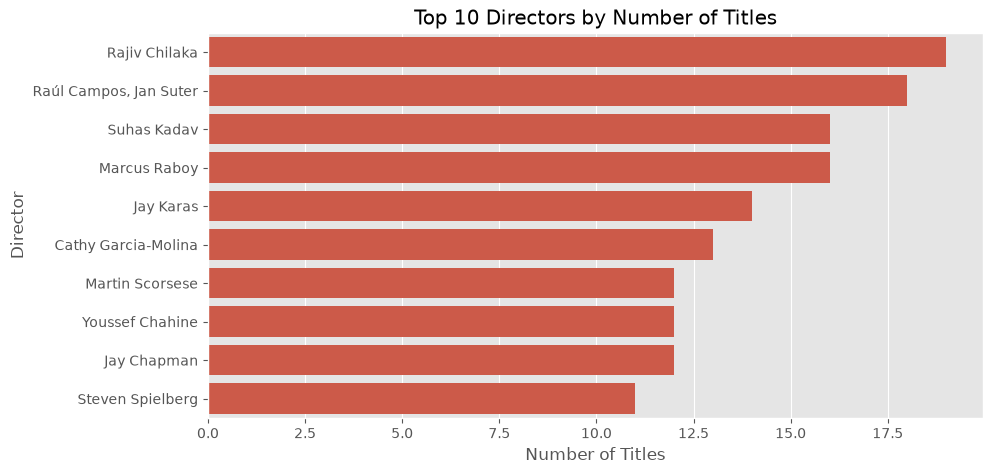

In [35]:
top_directors = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

### Insight

A small number of directors have contributed multiple titles to the Netflix catalog. Understanding content creators helps identify influential contributors and content trends.

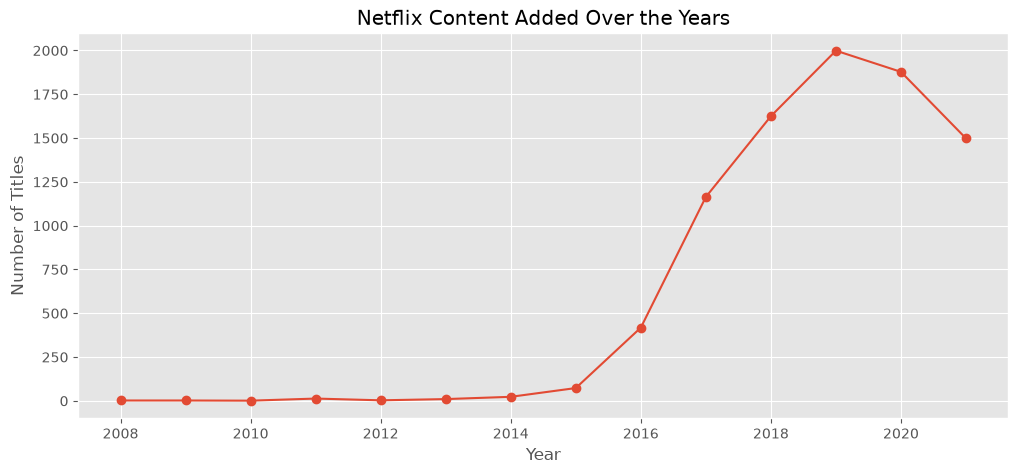

In [37]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

content_by_year = (
    df["date_added"]
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    content_by_year.index,
    content_by_year.values,
    marker="o"
)

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

### Insight

Netflix expanded its content library significantly over recent years before stabilizing. This trend reflects increased investment in original and licensed content.

In [38]:
import pickle

In [39]:
with open("recommendation_model.pkl", "wb") as file:
    pickle.dump(similarity_matrix, file)

print("Recommendation model saved successfully.")

Recommendation model saved successfully.


In [40]:
with open("recommendation_model.pkl", "wb") as file:
    pickle.dump(similarity_matrix, file)

print("Recommendation model saved successfully.")

Recommendation model saved successfully.


In [41]:
df.to_csv(
    "processed_netflix_titles.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Project Summary

## Objective

Develop an AI-powered content-based recommendation system capable of suggesting similar Netflix movies and TV shows based on their metadata.

## Key Achievements

- Loaded and explored the Netflix dataset.
- Performed data cleaning and preprocessing.
- Conducted exploratory data analysis.
- Learned content patterns using TF-IDF.
- Calculated similarity using Cosine Similarity.
- Built a recommendation engine.
- Evaluated recommendation quality.
- Discussed ethical considerations.
- Proposed deployment and monitoring strategies.
- Saved the trained recommendation model for future use.

## Technologies Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- TF-IDF Vectorizer
- Cosine Similarity
- Pickle